<a href="https://colab.research.google.com/github/gem569/wave-equation-pca/blob/main/PCA_WE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA on the Wave equation

### **Why do PCA on wave equation data?**

- When simulating a wave, each snapshot in time is a high-dimensional vector. PCA can help to compress this data to a few components which capture most of the wave's behaviour.

- Using this, we can then identify dominant patters in the wave, observing the main 'shapes' it takes.

- We can also filter noise, PCA can remove small random variations while keeping the main structure.

### **The Principal components and scores:**

The principal component (PC) loadings show directions in space that capture the most variance. Here, this will be a spatial pattern of the wave that explains most of the motion.

The PC scores show the projection of our data onto the PCs. In this case, the $k^{\text{th}}$ PC scores tells us how much of the $k^{\text{th}}$ spacial pattern is present at that time.

### **Reconstructing the solution:**

When we reconstruct the wave using just the first few PCs, we keep only the main behaviour and compress the data.

This makes it much easier to analyse how the main patterns evolve over time.

By comparing the original and reconstructed waves, we can detect anomalies in the data. These anomalies won't be captured by the main PC loadings, so we simply look for differences.

In [1]:
#Importing libraries:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## Solving the wave equation
We begin with the 1D wave equation:
\begin{align}
  \partial_t^2 u = c^2 \partial_x^2 u, \\
  x \in [0,L], \\
  t \in [0,T], \\
  u(0,t) = u(1,t) = 0, \\
  u(x,0) = \Phi(x), \\
  \partial_t u(x,0) = V(x).
\end{align}

To approximate a solution we will implement a finite difference scheme. We convert the second time derivative into
\begin{align}
  u_i^{(n+1)} = 2u_i^{(n)} - u_i^{(n-1)} + r^2 \left(u_{i+1}^{(n)} - 2u_i^{(n)} + u_{i-1}^{(n)} \right),
\end{align}
where
$$ r = \frac{c \Delta t}{\Delta x} $$
is such that $r \leq 1$, this is known as the stability condition.

In [2]:
def sol_we(Phi, V, c=1.0, L=1.0, T=1.0, Nx=50, Nt=100):

  #Solving the 1D wave equation with Dirichlet BCs:

  #Returns:
  #  x: spatial grid
  #  t: time grid
  #  u: solution matrix

  dx = L / (Nx - 1)
  dt = T / (Nt)

  #Checking stability condition
  r = c * dt/dx
  if r > 1:
    raise ValueError("Stability condition not satisfied.")

  x = np.linspace(0, L, Nx)
  t = np.linspace(0, T, Nt)

  #Creating the solution array
  u = np.zeros((Nx,Nt))
  u[:,0] = Phi(x)
  u[:,1] = Phi(x) + dt * V(x)

  #Implementing a finite differences scheme
  for n in range(1, Nt-1):
    for i in range(1, Nx-1):
      u[i, n+1] = 2*u[i, n] - u[i, n-1] + r**2 * (u[i+1, n] - 2*u[i, n] + u[i-1, n])

    #Boundary conditions
    u[0, n+1] = 0
    u[-1, n+1] = 0

  return x, t, u

## The PCA process
We must now implement the PCA process to a general matrix X, then apply this to our solution matrix u.

In [3]:
def pca(X):

  #Performs PCA on a given matrix X, using SVD.
  #Returns:
  #  U: matrix of PC loading vectors
  #  S: singular values, variability of each PC score
  #  Vt: PC scores
  #  X_mean: mean of X
  #  energy: proportion of variance explained by PC k.

  X_mean = X.mean(axis=1, keepdims = True)
  Xc = X - X_mean

  #SVD
  U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

  energy = S**2 / np.sum(S**2)

  return U, S, Vt, X_mean, energy


### Reconstructing the solution using PCA
The solution is reconstructed by projected onto the first few PC loadings, yielding an approximation which preserves most of the main behaviour.

In [4]:
def reconstruct_pca(U, S, Vt, X_mean, r):
  #Reconstruct data using r PCA loadings:
  return ( X_mean + U[:, :r] @ np.diag(S[:r]) @ Vt[:r,:] )

## Applying to the wave equation

In [5]:
#Initial conditions
def Phi(x):
  return np.exp(-((x-0.5)**2) / (2* 0.05**2))

def V(x):
  return np.zeros_like(x)

#Parameters
c=1.0
L=1.0
T=1.0
Nx=50
Nt=100

#Generating solution matrix
x, t, u = sol_we(Phi, V)

#Applying PCA
U, S, Vt, X_mean, energy = pca(u)

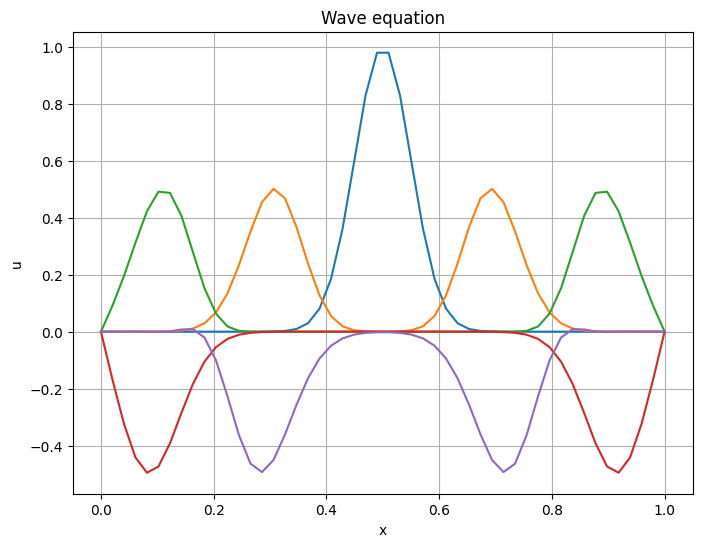

In [6]:
#Plotting our solution at various time steps
plt.figure(figsize=(8,6))
for n in [0,20,40,60,80]:
  plt.plot(x, u[:, n], label=f"t = {n}")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Wave equation")
plt.grid()
plt.show()

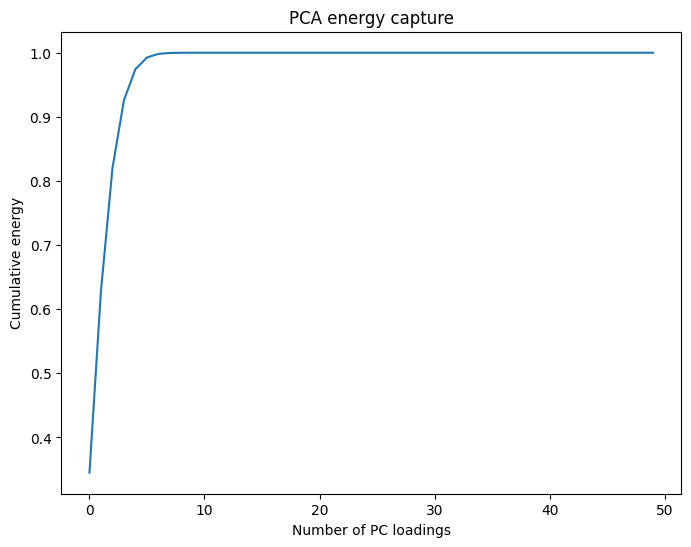

In [7]:
#Plotting the proportion of variability captured at each PC score
plt.figure(figsize=(8,6))
plt.plot(np.cumsum(energy))
plt.xlabel("Number of PC loadings")
plt.ylabel("Cumulative energy")
plt.title("PCA energy capture")
plt.show()

No more than 5 or 6 PC loading vectors are needed to present more than 90% of the variability, thus we use 5 here.

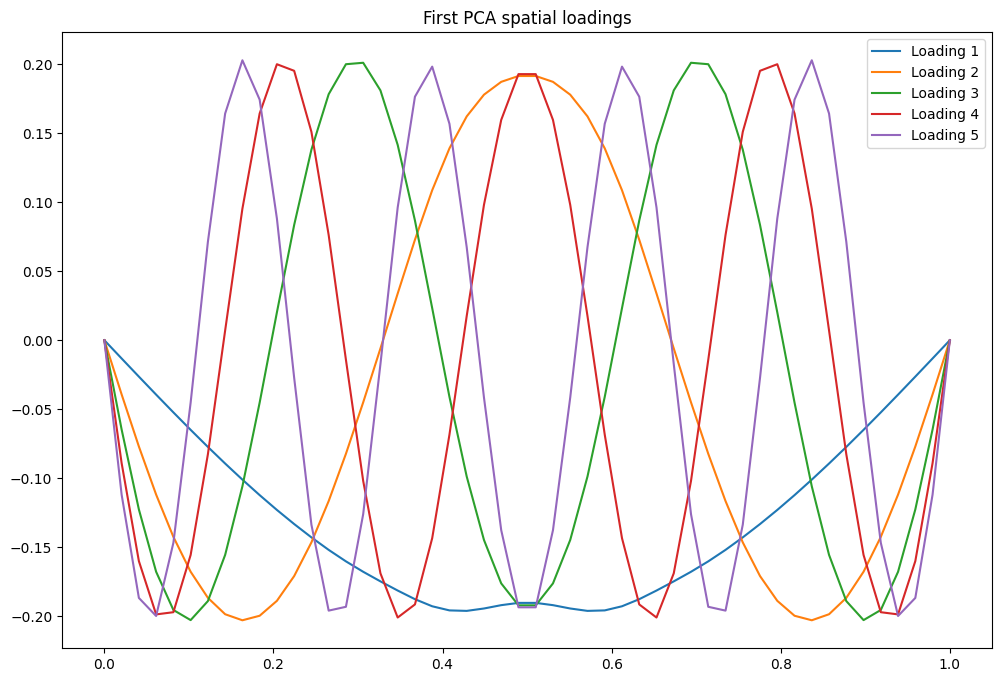

In [8]:
#Plot first k PC loadings
plt.figure(figsize=(12,8))
for k in range(5):
  plt.plot(x, U[:, k], label = f"Loading {k+1}")

plt.legend()
plt.title("First PCA spatial loadings")
plt.show()

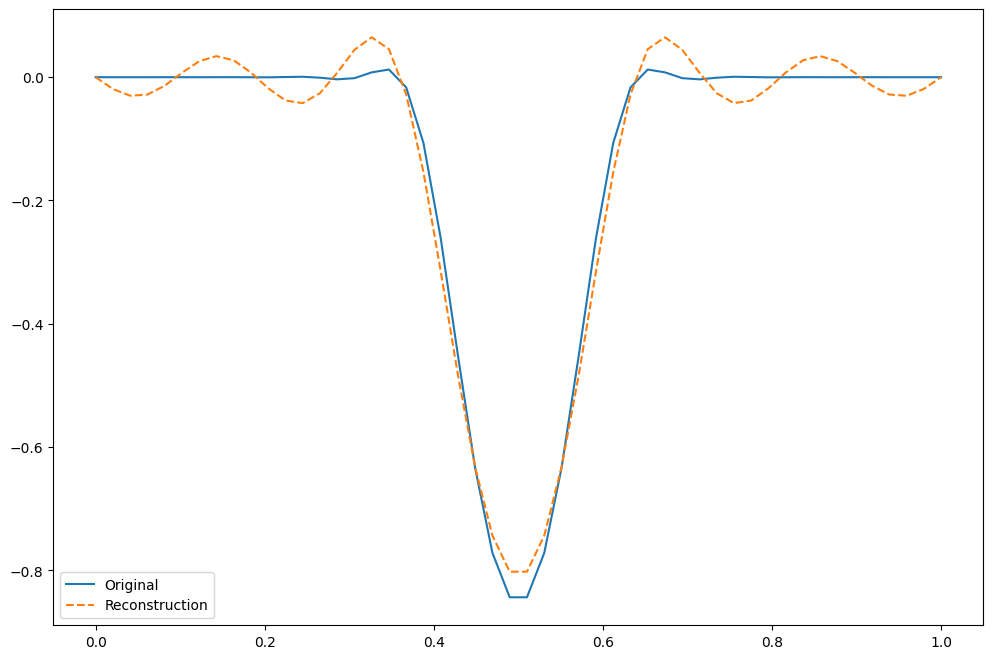

In [9]:
#Reconstucting wave equation
u_rec = reconstruct_pca(U, S, Vt, X_mean, r=5)

#Plotting results
plt.figure(figsize=(12,8))
plt.plot(x, u[:, -1], label = "Original")
plt.plot(x, u_rec[:, -1], "--", label = "Reconstruction")
plt.legend()
plt.show()